# Gridded Flood-Event Demonstration: January 2011, Southeast Queensland

**These indices describe flood potential, not flooding.** They summarize how wet
the recent past has been. Whether that wetness becomes a flood depends on
terrain, soils, land cover, and river routing, none of which appear here. A high
value never establishes that a flood occurred, where, or how severe it was.

This notebook computes the Flood Index (I_F), the Antecedent Precipitation Index
(API), and the wet tail of SPI on one daily gridded precipitation product around
the January 2011 Brisbane and Lockyer Valley floods analysed by Deo et al. (2015),
and compares them at the grid cell nearest Brisbane.

It is a demonstration of how the pieces fit together on a real grid. It does not
reproduce the numbers in Deo et al. (2015), which used a different (not readily
available) record, and the library's I_F is specification-level: no numeric
external oracle exists yet (see ADR-0014 and `docs/algorithm_refs/flood_index.md`).

## Data source and terms

| | |
| --- | --- |
| Product | NOAA PSL distribution of the CPC Global Unified Gauge-Based Analysis of Daily Precipitation (file title `CPC GLOBAL PRCP V1.0`), 0.5 degree daily, land cells only |
| Product page | <https://psl.noaa.gov/data/gridded/data.cpc.globalprecip.html> |
| Files | `https://psl.noaa.gov/thredds/ncss/grid/Datasets/cpc_global_precip/precip.YYYY.nc`, subset server-side with the THREDDS NetCDF Subset Service (`ncss`) |
| Subset | `var=precip`, `north=-24`, `south=-30`, `west=150`, `east=156` (13 x 13 cells, centres 24.25 to 30.25 S and 150.25 to 156.25 E) |
| Period | 1979-01-01 to 2011-12-31, one request per year (33 files of about 250 KB) |
| Terms | The product page asks users to acknowledge PSL: "data provided by the NOAA PSL, Boulder, Colorado, USA, from their website at https://psl.noaa.gov" and says copies of publications help "PSL to justify keeping the data freely available online in the future". It publishes no explicit license; nothing is redistributed here, since the cache stays git-ignored. Checked 2026-09-25. |
| Storage | Cached under the git-ignored `data/flood-demo/`; nothing is committed |

The first run downloads the 33 subsets, which takes a few minutes because the
server subsets each file on request; later runs read the cache. To check that the
notebook still executes end to end from a fresh kernel without rewriting this
file, run from the repository root:

```bash
uv run --group dev jupyter nbconvert --execute --to notebook \
  --output-dir "$(mktemp -d)" notebooks/flood_event_brisbane_2011.ipynb
```

No CI job runs this notebook, because it needs the network.


In [1]:
import logging
import shutil
import urllib.request
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from climate_indices import flood, spi
from climate_indices.exceptions import MissingDataWarning
from climate_indices.indices import Distribution

logging.disable(logging.CRITICAL)

DATA_DIR = Path("../data/flood-demo")
FIRST_YEAR, LAST_YEAR = 1979, 2011
NCSS_URL = (
    "https://psl.noaa.gov/thredds/ncss/grid/Datasets/cpc_global_precip/precip.{year}.nc"
    "?var=precip&north=-24&south=-30&west=150&east=156"
    "&time_start={year}-01-01T00:00:00Z&time_end={year}-12-31T00:00:00Z&accept=netcdf"
)


def fetch_year(year: int) -> Path:
    """Download one year of the regional subset unless it is already cached."""
    target = DATA_DIR / f"cpc_precip_{year}.nc"
    if not target.exists():
        partial = target.with_suffix(".part")
        with urllib.request.urlopen(NCSS_URL.format(year=year), timeout=300) as response, partial.open("wb") as out:
            shutil.copyfileobj(response, out)
        partial.replace(target)
    return target


DATA_DIR.mkdir(parents=True, exist_ok=True)
with ThreadPoolExecutor(max_workers=4) as pool:
    files = list(pool.map(fetch_year, range(FIRST_YEAR, LAST_YEAR + 1)))

len(files)


33

## Load the record and handle gaps

CPC covers land only, so ocean cells are (almost) entirely missing and are masked
out. Land cells are missing a handful of isolated days: the same single day
everywhere, and a few more in the western cells. The indices need a continuous
daily series, so the cell below fills those days with 0 mm and prints exactly which
days were filled. That is a small underestimate of rainfall on those days; it
matters most for the western cells, which miss three days just before the event,
so read their values as lower bounds.


In [2]:
raw = xr.open_mfdataset(files)["precip"].load()

expected_days = pd.date_range(f"{FIRST_YEAR}-01-01", f"{LAST_YEAR}-12-31")
assert raw.time.size == expected_days.size
assert (raw.time.diff("time") == pd.Timedelta("1D")).all()
assert raw.attrs["units"] == "mm"

land = raw.notnull().mean("time") > 0.99
missing = raw.isnull() & land
missing_per_cell = missing.sum("time").values[land.values]
assert missing_per_cell.max() <= 6, "unexpected gap volume; the zero-fill rationale no longer holds"

print(f"{int(land.sum())} land cells of {land.size}; missing days per land cell: {sorted(set(missing_per_cell.tolist()))}")
print("Days with a missing land value:", pd.DatetimeIndex(raw.time.values[missing.any(("lat", "lon")).values]).strftime("%Y-%m-%d").tolist())

precip = raw.fillna(0.0).where(land)
precip.attrs = raw.attrs
dict(precip.sizes)


91 land cells of 169; missing days per land cell: [1, 6]
Days with a missing land value: ['2007-02-26', '2010-08-27', '2011-01-03', '2011-01-04', '2011-01-05', '2011-12-02']


{'time': 12053, 'lat': 13, 'lon': 13}

## Compute the indices

- **Effective precipitation (PE)** is the shared input to I_F. The default 365-day
  window leaves PE undefined for the first 364 days of the record. PE here is the
  harmonic double sum of Byun and Wilhite (1999) Eq. (2), the kernel this package
  implements (ADR-0014), not the exponentially decaying form described in the Deo
  et al. (2015) abstract; the two are not algebraically equivalent.
- **Flood Index (I_F)** standardizes daily PE against the annual maxima of PE in a
  calibration period. The calibration covers 30 annual periods that begin in
  October 1980 and end in September 2010, so the January 2011 event lies outside
  the period used to calibrate it, and the first (partly undefined) PE year is
  excluded. `year_start_month=10` is this notebook's choice, not a published
  convention: no start month is recoverable from Deo et al. (2015), and the
  library never infers one (ADR-0014). October keeps the November-to-March wet
  season inside a single annual period.
- **API** is the recursion `API_t = k * API_(t-1) + P_t` in mm. `k=0.9` is the top of
  the 0.85 to 0.90 range that ADR-0014 records as typical, after Kohler and Linsley
  (1951).
- **SPI-3** uses monthly totals of the same daily series and a gamma fit over
  calendar years 1980 to 2009. It is the wet tail of a drought index, and the
  library clips SPI to [-3.09, 3.09].


In [3]:
pe = flood.effective_precipitation(precip)
flood_idx = flood.flood_index(pe, calibration_year_initial=1980, calibration_year_final=2009, year_start_month=10)
api = flood.antecedent_precipitation_index(precip, k=0.9)

monthly = precip.resample(time="MS").sum(skipna=False)
with warnings.catch_warnings():
    # ocean cells are entirely missing: the calibration-missing-data warning and the
    # numpy empty-slice warning describe those cells, not the land cells analysed here
    warnings.simplefilter("ignore", MissingDataWarning)
    warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)
    spi_3 = spi(monthly, scale=3, distribution=Distribution.gamma, calibration_year_initial=1980, calibration_year_final=2009)

assert flood_idx.dims == precip.dims and api.dims == precip.dims
assert flood_idx.attrs["long_name"] == "Flood Index"
assert api.attrs["units"] == "mm"
assert spi_3.attrs["long_name"] == "Standardized Precipitation Index"

print(f"I_F over land cells and all days: {float(flood_idx.min()):.2f} to {float(flood_idx.max()):.2f}")
print(f"API over land cells and all days: {float(api.min()):.1f} to {float(api.max()):.1f} mm")


I_F over land cells and all days: -5.22 to 7.63
API over land cells and all days: 0.0 to 631.6 mm


## Compare the indices at the cell nearest Brisbane

The table gives each index's peak over November 2010 to February 2011 and how that
year's maximum ranks among the 31 annual (October to September) maxima from 1980
to 2011 at the same cell. Rank 1 is the highest. SPI-3 is monthly and clipped at
3.09, so it can tie.


In [4]:
BRISBANE = {"lat": -27.47, "lon": 153.03}
event_window = slice("2010-11-01", "2011-02-28")

cell = {k: float(v) for k, v in flood_idx.sel(**BRISBANE, method="nearest").coords.items() if k in BRISBANE}
series = {
    "Flood Index (I_F)": flood_idx.sel(**cell),
    "API (mm)": api.sel(**cell),
    "SPI-3": spi_3.sel(**cell),
}


def summarize(name: str, values: xr.DataArray) -> dict[str, object]:
    in_event = values.sel(time=event_window)
    annual_max = values.sel(time=slice("1980-10-01", "2011-09-30")).resample(time="YS-OCT").max()
    event_year = annual_max.sel(time="2010-10-01")
    return {
        "index": name,
        "event-window peak": round(float(in_event.max()), 2),
        "peak date": pd.Timestamp(in_event.idxmax().values).strftime("%Y-%m-%d"),
        "annual-max rank": f"{int((annual_max > event_year).sum()) + 1} of {annual_max.size}",
    }


print(f"Grid cell nearest Brisbane: {abs(cell['lat']):.2f} S, {cell['lon']:.2f} E")
comparison = pd.DataFrame([summarize(name, values) for name, values in series.items()]).set_index("index")
assert comparison.loc["Flood Index (I_F)", "peak date"] == "2011-01-11"
assert comparison.loc["Flood Index (I_F)", "annual-max rank"] == "2 of 31"
assert comparison.loc["API (mm)", "annual-max rank"] == "8 of 31"
comparison


Grid cell nearest Brisbane: 27.25 S, 153.25 E


,event-window peak,peak date,annual-max rank
index,,,
Flood Index (I_F),2.18,2011-01-11,2 of 31
API (mm),223.16,2011-01-11,8 of 31
SPI-3,3.09,2010-12-01,1 of 31


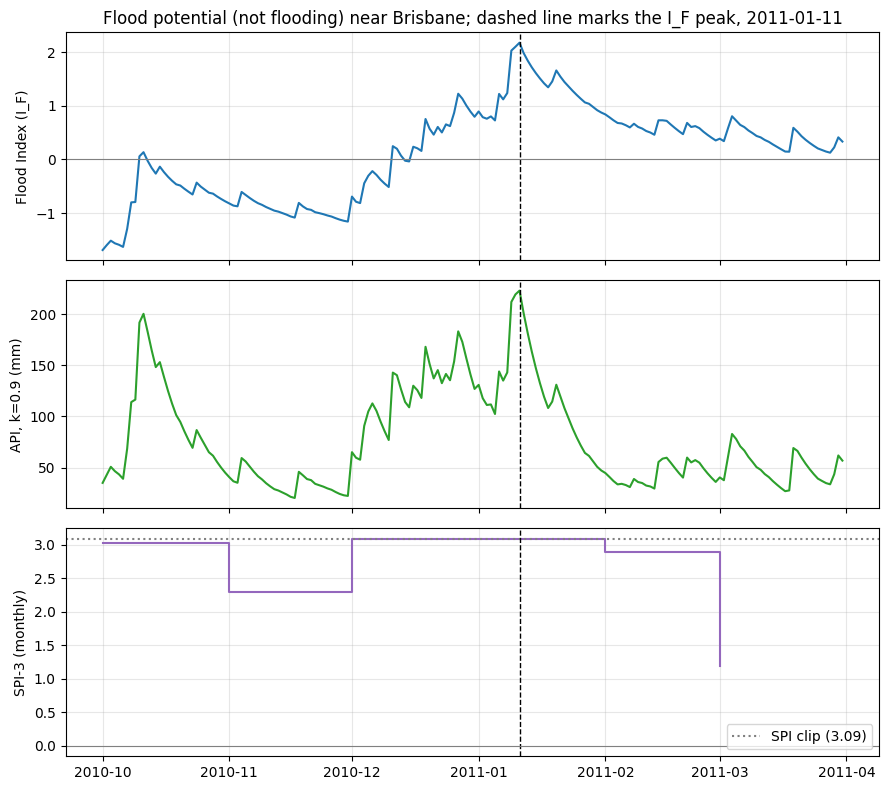

In [5]:
window = slice("2010-10-01", "2011-03-31")
peak_day = pd.Timestamp(series["Flood Index (I_F)"].sel(time=event_window).idxmax().values)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
flood_idx_cell = series["Flood Index (I_F)"].sel(time=window)
axes[0].plot(flood_idx_cell.time, flood_idx_cell, color="tab:blue")
axes[0].set_ylabel("Flood Index (I_F)")
api_cell = series["API (mm)"].sel(time=window)
axes[1].plot(api_cell.time, api_cell, color="tab:green")
axes[1].set_ylabel("API, k=0.9 (mm)")
spi_cell = series["SPI-3"].sel(time=window)
axes[2].step(spi_cell.time, spi_cell, where="post", color="tab:purple")
axes[2].axhline(3.09, color="grey", linestyle=":", label="SPI clip (3.09)")
axes[2].set_ylabel("SPI-3 (monthly)")
axes[2].legend(loc="lower right")
for ax in axes:
    ax.axvline(peak_day, color="black", linestyle="--", linewidth=1)
    ax.grid(alpha=0.3)
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[2].axhline(0, color="grey", linewidth=0.8)
axes[0].set_title(f"Flood potential (not flooding) near Brisbane; dashed line marks the I_F peak, {peak_day:%Y-%m-%d}")
plt.tight_layout()
plt.show()


## Map the same day and month

White cells have no CPC estimate (ocean). The star marks the cell nearest Brisbane.
The three panels are on different scales: I_F and SPI-3 are dimensionless
standardized values, and API is a wetness total in mm.


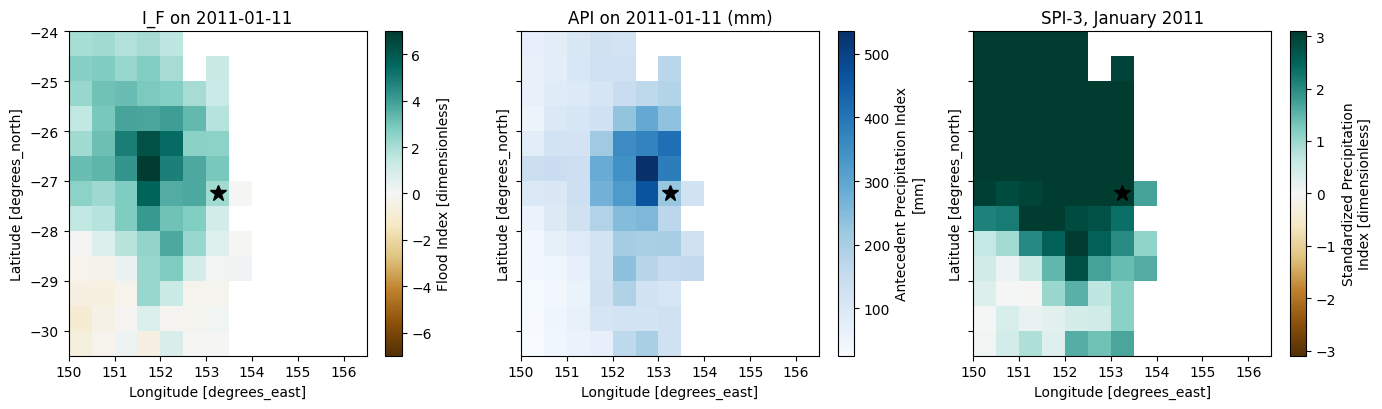

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
panels = [
    (flood_idx.sel(time=peak_day), f"I_F on {peak_day:%Y-%m-%d}", "BrBG", {"center": 0}),
    (api.sel(time=peak_day), f"API on {peak_day:%Y-%m-%d} (mm)", "Blues", {}),
    (spi_3.sel(time=f"{peak_day:%Y-%m-01}"), f"SPI-3, {peak_day:%B %Y}", "BrBG", {"center": 0}),
]
for ax, (field, title, cmap, kwargs) in zip(axes, panels):
    field.plot.pcolormesh(ax=ax, cmap=cmap, **kwargs)
    ax.plot(cell["lon"], cell["lat"], marker="*", color="black", markersize=12)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## How to read this

- **What it shows.** At the Brisbane cell the two daily indices peak on the same
  day but rank the 2010-11 season differently. I_F, which standardizes a 365-day
  effective-precipitation window, puts it second among the 31 October-to-September
  maxima; API, whose `k=0.9` forgets over roughly ten days, puts it eighth. They
  answer different questions (how wet the year has been, against how much rain fell
  in the last week or two), so they need not agree on rank. SPI-3 sits at its 3.09
  clip in December 2010 and January 2011, and the January map is at or near the clip
  across most of the land cells north of about 28 S. It marks the season as
  extremely wet but cannot rank the wettest places, while the daily indices keep
  discriminating (the largest I_F values on the peak day lie inland, west of
  Brisbane). That is a difference in resolution and range, not in correctness.
- **What it does not show.** None of these values says whether the Brisbane River or
  the Lockyer Valley flooded, how deep, or with what impact. A 0.5 degree cell
  (about 50 km) is far coarser than a river catchment, and the daily totals here are
  a gridded analysis of gauges, not observed catchment rainfall.
- **Data caveats.** Missing days were filled with 0 mm (listed above), which
  understates rainfall on those days and matters most in the western cells just
  before the event. The product is land-only.
- **Method caveats.** The calibration period, the October year start, and `k` are
  choices made for this demonstration. I_F is specification-level (ADR-0014); the
  library provides no flood-event detection, so there is no event onset, duration,
  or severity here.

Use I_F, API, and the SPI wet tail as hydroclimate context and wet-extreme
situational awareness, not as flood forecasts. See `docs/flood_applications.md`
for the wider family and its scope boundary.

**References**

- Deo, R. C., Byun, H.-R., Adamowski, J. F., and Kim, D.-W. (2015). A real-time
  flood monitoring index based on daily effective precipitation and its
  application to Brisbane and Lockyer Valley flood events. *Water Resources
  Management*, 29, 4075-4093. <https://doi.org/10.1007/s11269-015-1046-3>
- Byun, H.-R., and Wilhite, D. A. (1999). Objective quantification of drought
  severity and duration. *Journal of Climate*, 12, 2747-2756.
- Kohler, M. A., and Linsley, R. K. (1951). *Predicting the runoff from storm
  rainfall*. U.S. Weather Bureau Research Paper 34.
- Data provided by the NOAA PSL, Boulder, Colorado, USA, from their website at
  <https://psl.noaa.gov>.
